<a href="https://colab.research.google.com/github/debashisdotchatterjee/Bayesian-LPP-with-Posterior-Feasibility-Guarantees/blob/main/Bayesian_LPP_1_Bayesian_Linear_Programming_with_Posterior_Feasibility_Guarantees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 5.8 MB/s eta 0:00:00


alpha=0.1: 100%|██████████| 60/60 [00:02<00:00, 24.05it/s]


,alpha,trial,method,status,profit,viol_true,viol_post_hat,viol_post_ub_95
0,0.01,0,PM,optimal,855.539492,0.8366,0.9422,0.947536
1,0.01,0,CR,optimal,653.719677,0.0002,0.0040,0.005807
2,0.01,0,PS,optimal,634.630676,0.0016,0.0068,0.009043
3,0.01,0,FPQ,optimal,641.645296,0.0002,0.0020,0.003390
4,0.01,0,RB,optimal,659.048778,0.0002,0.0052,0.007208
5,0.01,1,PM,optimal,756.123915,0.9552,0.9430,0.948300
6,0.01,1,CR,optimal,547.622627,0.0120,0.0056,0.007670
7,0.01,1,PS,optimal,567.050525,0.0242,0.0134,0.016397
8,0.01,1,FPQ,optimal,535.159485,0.0084,0.0032,0.004856
9,0.01,1,RB,optimal,553.012347,0.0134,0.0072,0.009497


,alpha,method,n_runs,profit_mean,profit_sd,viol_true_mean,viol_true_sd,viol_post_hat_mean,viol_post_ub95_mean
0,0.01,CR,60,556.254703,94.808982,0.007287,0.008000,0.004763,0.006677
1,0.01,FPQ,60,543.783231,96.551642,0.004713,0.005655,0.002783,0.004332
2,0.01,PM,60,759.591295,79.471323,0.905057,0.085939,0.912123,0.918372
3,0.01,PS,60,558.324521,101.454163,0.012693,0.012545,0.009080,0.011512
4,0.01,RB,60,561.761246,94.224209,0.009023,0.009668,0.006100,0.008217
5,0.05,CR,60,582.629594,80.320864,0.030157,0.016905,0.023857,0.027694
6,0.05,FPQ,60,572.399698,80.866570,0.020973,0.012312,0.016500,0.019756
7,0.05,PM,60,751.345488,77.313932,0.929137,0.052198,0.930883,0.936508
8,0.05,PS,60,551.411863,87.730060,0.014010,0.010775,0.011737,0.014448
9,0.05,RB,60,585.819676,80.202519,0.033800,0.018450,0.027043,0.031100


,method,n_runs,profit_mean,profit_sd,viol_true_mean,viol_post_hat_mean,viol_post_ub95_mean
0,CR,180,587.057737,88.964254,0.031060,0.025153,0.028798
1,FPQ,180,576.539632,90.522046,0.022713,0.017864,0.020968
2,PM,180,759.027394,75.277073,0.916781,0.921220,0.927190
3,PS,180,559.200131,90.137385,0.013052,0.010088,0.012629
4,RB,180,590.733017,88.289224,0.034422,0.028083,0.031937


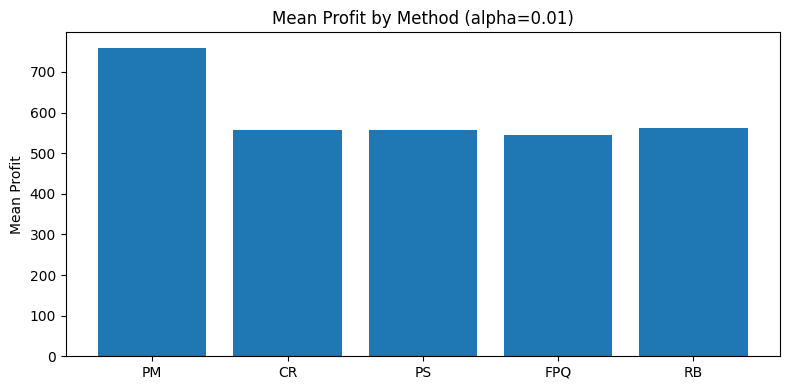

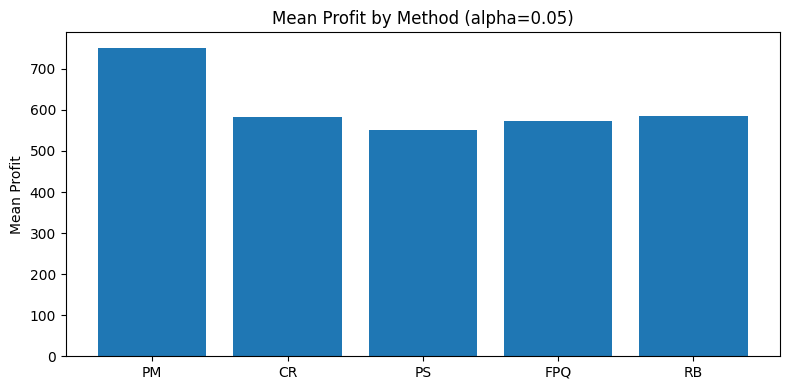

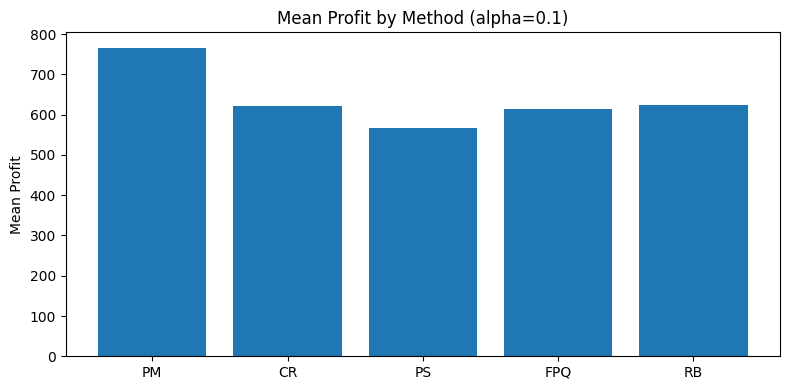

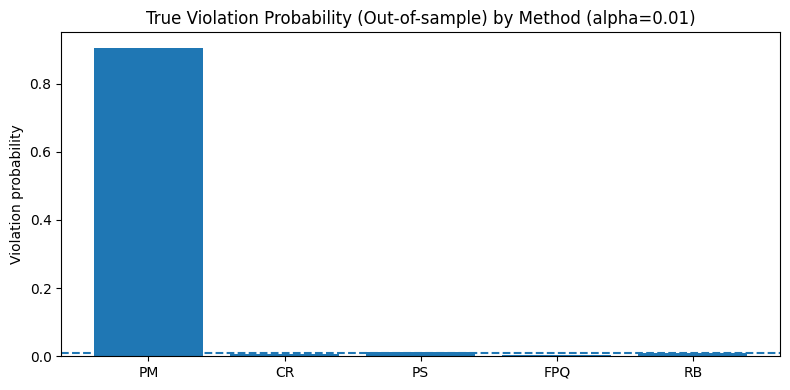

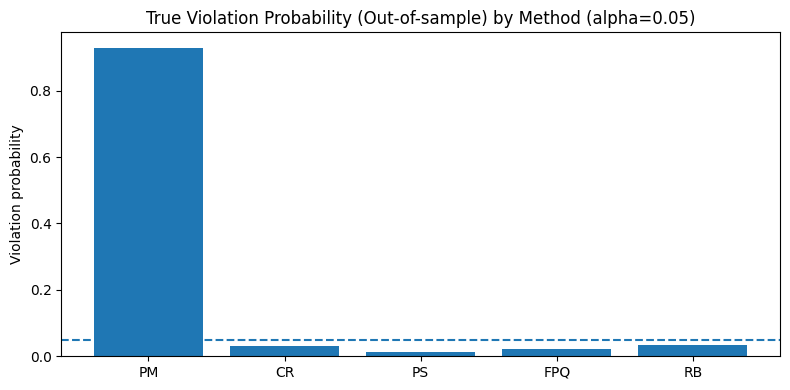

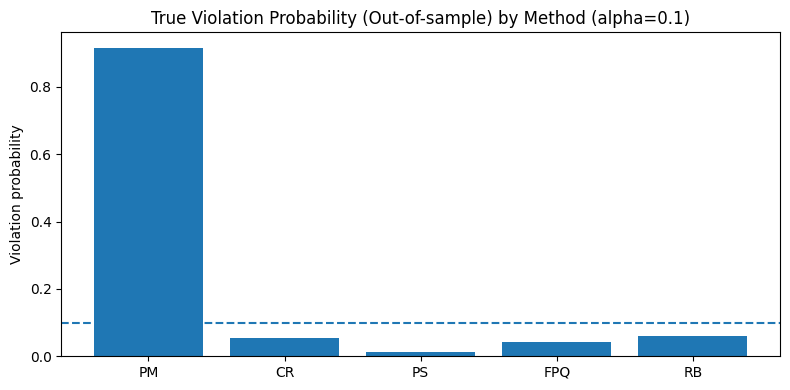

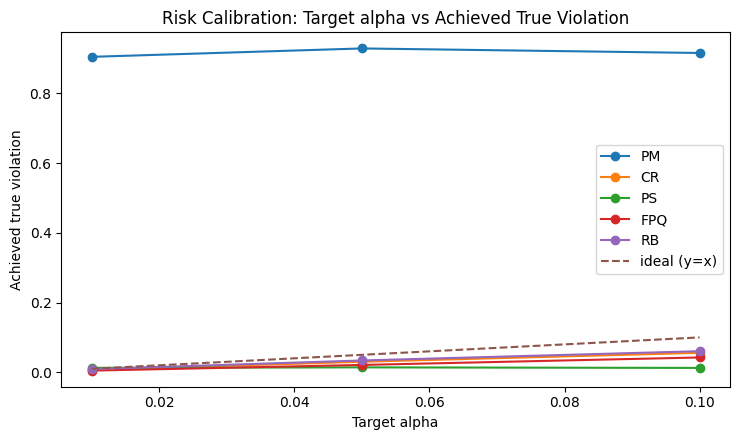

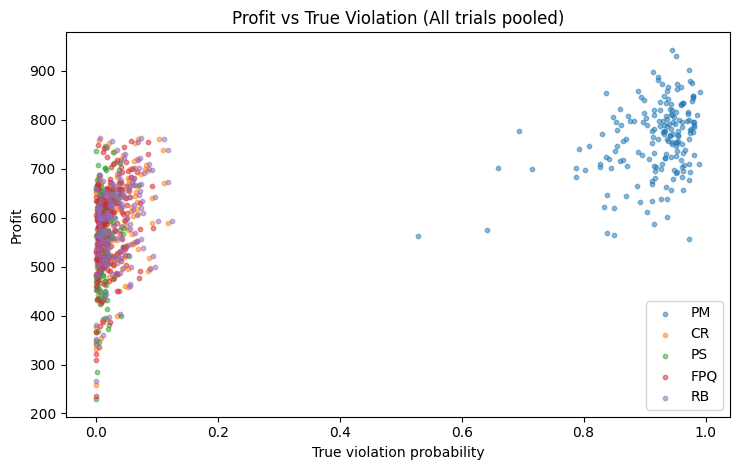

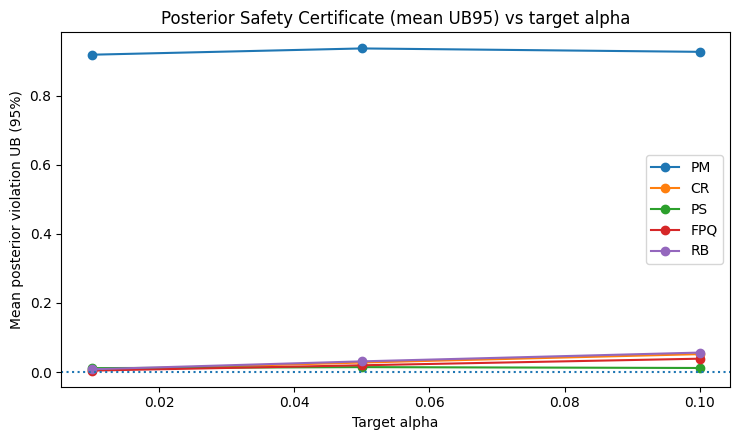

,alpha,best_lowest_violation,best_highest_profit
0,0.01,FPQ,PM
1,0.05,PS,PM
2,0.10,PS,PM


Saved outputs to: BLP_PosteriorFeasibility_20260306_022834
Zipped as: BLP_PosteriorFeasibility_20260306_022834.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Summary by alpha & method ===
 alpha method  n_runs  profit_mean  profit_sd  viol_true_mean  viol_true_sd  viol_post_hat_mean  viol_post_ub95_mean
0.0100     CR      60     556.2547    94.8090          0.0073        0.0080              0.0048               0.0067
0.0100    FPQ      60     543.7832    96.5516          0.0047        0.0057              0.0028               0.0043
0.0100     PM      60     759.5913    79.4713          0.9051        0.0859              0.9121               0.9184
0.0100     PS      60     558.3245   101.4542          0.0127        0.0125              0.0091               0.0115
0.0100     RB      60     561.7612    94.2242          0.0090        0.0097              0.0061               0.0082
0.0500     CR      60     582.6296    80.3209          0.0302        0.0169              0.0239               0.0277
0.0500    FPQ      60     572.3997    80.8666          0.0210        0.0123              0.0165               0.0198
0.0500     PM      60     751

In [1]:
# ============================================================
# Google Colab Notebook Script
# Bayesian Linear Programming with Posterior Feasibility Guarantees
# Simulation study + comparisons + plots/tables + auto-saved ZIP
# ============================================================

# ----------------------------
# 0) Install & imports
# ----------------------------
!pip -q install cvxpy ecos tqdm pandas scipy matplotlib

import os, time, json, zipfile, shutil
from dataclasses import dataclass
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import stats
import cvxpy as cp

# Colab download helper
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

np.set_printoptions(precision=4, suppress=True)

# ----------------------------
# 1) Config
# ----------------------------
@dataclass
class Config:
    seed: int = 123
    trials: int = 60              # Monte Carlo replications
    n_products: int = 18          # decision dimension n
    m_resources: int = 7          # number of uncertain constraints m
    d_features: int = 6           # regression features incl. intercept
    N_obs: int = 90               # data points per trial for learning
    MC_eval: int = 5000           # true out-of-sample evaluation samples
    # scenario sample sizes for posterior-scenario and certification
    N_post_scen: int = 300        # posterior predictive scenarios used in PS solve
    M_cert: int = 5000            # independent posterior predictive samples for certification diagnostic
    # LP bounds
    x_max: float = 50.0
    # risk levels to test
    alphas = (0.01, 0.05, 0.10)

CFG = Config()

# Output directory
RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")
BASE_DIR = f"BLP_PosteriorFeasibility_{RUN_STAMP}"
FIG_DIR = os.path.join(BASE_DIR, "figs")
TAB_DIR = os.path.join(BASE_DIR, "tables")
META_DIR = os.path.join(BASE_DIR, "meta")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

with open(os.path.join(META_DIR, "config.json"), "w") as f:
    json.dump(CFG.__dict__, f, indent=2)

rng_global = np.random.default_rng(CFG.seed)

# ----------------------------
# 2) Model: resource capacities learned by Bayesian linear regression
#    For each resource j=1..m:
#        y = X beta_j + eps, eps ~ N(0, sigma_j^2)
#    Prior: (beta_j, sigma_j^2) ~ Normal-Inverse-Gamma (conjugate)
#    Posterior predictive: Student-t
# ----------------------------

def make_design_matrix(F_raw):
    """
    F_raw: (N, d_features-1) WITHOUT intercept.
    Returns X: (N, d_features) with intercept as first column.
    """
    N = F_raw.shape[0]
    X = np.ones((N, 1))
    return np.hstack([X, F_raw])

def nig_posterior(X, y, m0, V0, a0, b0):
    """
    Conjugate Normal-Inverse-Gamma posterior for Bayesian linear regression.
    Prior:
      beta | sigma^2 ~ N(m0, sigma^2 V0)
      sigma^2 ~ InvGamma(a0, b0)  (shape a0, scale b0)
    Posterior:
      beta | sigma^2, D ~ N(mn, sigma^2 Vn)
      sigma^2 | D ~ InvGamma(an, bn)
    """
    # V0 is covariance-like, so V0^{-1} appears
    V0_inv = np.linalg.inv(V0)
    XtX = X.T @ X
    Vn = np.linalg.inv(V0_inv + XtX)
    mn = Vn @ (V0_inv @ m0 + X.T @ y)
    an = a0 + X.shape[0] / 2.0
    # bn formula:
    # bn = b0 + 0.5*(y'y + m0'V0^{-1}m0 - mn'Vn^{-1}mn)
    term = (y.T @ y) + (m0.T @ V0_inv @ m0) - (mn.T @ np.linalg.inv(Vn) @ mn)
    bn = b0 + 0.5 * term
    return mn, Vn, an, bn

def posterior_predictive_params(x_new, mn, Vn, an, bn):
    """
    Posterior predictive for y_new at covariate x_new:
      y_new | D ~ StudentT(df=2an, loc=mu, scale=s)
    where
      mu = x_new' mn
      s^2 = (bn/an) * (1 + x_new' Vn x_new)
    """
    df = 2.0 * an
    mu = float(x_new.T @ mn)
    s2 = (bn / an) * (1.0 + float(x_new.T @ Vn @ x_new))
    s = float(np.sqrt(max(s2, 1e-12)))
    return df, mu, s

def sample_posterior_predictive(df, mu, s, size, rng):
    return stats.t.rvs(df=df, loc=mu, scale=s, size=size, random_state=rng)

def predictive_quantile(df, mu, s, q):
    return float(stats.t.ppf(q, df=df, loc=mu, scale=s))

# Frequentist OLS predictive (Student-t)
def ols_predictive_params(X, y, x_new):
    """
    Standard OLS predictive:
      y_new ~ t_{N-d}(loc=x_new beta_hat, scale=s * sqrt(1 + x_new'(X'X)^{-1} x_new))
    """
    N, d = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XtX_inv @ (X.T @ y)
    resid = y - X @ beta_hat
    s2 = (resid.T @ resid) / (N - d)
    loc = float(x_new.T @ beta_hat)
    scale = float(np.sqrt(max(s2, 1e-12) * (1.0 + float(x_new.T @ XtX_inv @ x_new))))
    df = N - d
    return df, loc, scale

# ----------------------------
# 3) LP solver
#    Maximize profit p^T x subject to A x <= b_eff, 0<=x<=x_max
# ----------------------------
def solve_lp(A, b_eff, p, x_max, solver="ECOS"):
    """
    Solve:
      maximize p^T x
      s.t. A x <= b_eff
           0 <= x <= x_max
    Returns dict with x, objective, status.
    """
    n = A.shape[1]
    x = cp.Variable(n, nonneg=True)
    constraints = [A @ x <= b_eff, x <= x_max]
    obj = cp.Maximize(p @ x)
    prob = cp.Problem(obj, constraints)
    try:
        prob.solve(solver=solver, verbose=False)
    except Exception:
        # fallback
        prob.solve(solver="SCS", verbose=False)

    return {
        "status": prob.status,
        "x": None if x.value is None else np.array(x.value).reshape(-1),
        "obj": None if prob.value is None else float(prob.value),
    }

# ----------------------------
# 4) Methods: PM, CR, PS, FPQ, RB
#    We target joint violation <= alpha using union bound alpha_j = alpha/m.
# ----------------------------
def b_eff_posterior_mean(pred_params_per_j):
    return np.array([mu for (df, mu, s) in pred_params_per_j], dtype=float)

def b_eff_credible_robust(pred_params_per_j, alpha_joint):
    """
    Credible-set robustification for RHS:
    enforce A x <= b_L where b_L is lower quantile per constraint
    with alpha_j = alpha_joint / m (union bound).
    """
    m = len(pred_params_per_j)
    alpha_j = alpha_joint / m
    bL = []
    for (df, mu, s) in pred_params_per_j:
        q = predictive_quantile(df, mu, s, alpha_j)
        bL.append(q)
    bL = np.array(bL, dtype=float)
    # floor at small nonnegative to avoid numerical infeasibility in extreme cases
    return np.maximum(bL, 0.0)

def b_eff_posterior_scenario(pred_params_per_j, N_scen, rng):
    """
    Posterior-scenario method:
    sample N_scen RHS vectors from posterior predictive;
    enforce all sampled constraints -> equivalent to A x <= componentwise min of samples.
    """
    m = len(pred_params_per_j)
    samples = np.zeros((N_scen, m))
    for j, (df, mu, s) in enumerate(pred_params_per_j):
        samples[:, j] = sample_posterior_predictive(df, mu, s, N_scen, rng)
    bmin = np.min(samples, axis=0)
    return np.maximum(bmin, 0.0)

def b_eff_freq_predictive_quantile(X, Ymat, x_new, alpha_joint):
    """
    Frequentist predictive quantile per resource via OLS Student-t predictive.
    """
    N, d = X.shape
    m = Ymat.shape[1]
    alpha_j = alpha_joint / m
    bL = []
    for j in range(m):
        df, loc, scale = ols_predictive_params(X, Ymat[:, j], x_new)
        q = float(stats.t.ppf(alpha_j, df=df, loc=loc, scale=scale))
        bL.append(q)
    bL = np.array(bL, dtype=float)
    return np.maximum(bL, 0.0)

def b_eff_robust_box(pred_params_per_j, alpha_joint):
    """
    Simple robust box heuristic:
      b_eff_j = mean_j - z_{1-alpha_j} * sd_j
    Here we use Normal z as heuristic, even though predictive is t.
    """
    m = len(pred_params_per_j)
    alpha_j = alpha_joint / m
    z = stats.norm.ppf(1.0 - alpha_j)  # positive
    b_eff = []
    for (df, mu, s) in pred_params_per_j:
        b_eff.append(mu - z * s)
    b_eff = np.array(b_eff, dtype=float)
    return np.maximum(b_eff, 0.0)

# ----------------------------
# 5) True data-generating process for simulation
#    We generate true betas and sigmas, then data, then future capacity distribution.
# ----------------------------
def generate_true_params(m, d, rng):
    """
    Generates true regression coefficients and noise scales for each resource.
    Ensures generally positive capacities by having a positive intercept.
    """
    # Intercept around 140..180
    beta_true = rng.normal(0, 8.0, size=(m, d))
    beta_true[:, 0] = rng.uniform(140, 180, size=m)          # intercept
    beta_true[:, 1:] += rng.normal(0, 5.0, size=(m, d-1))
    sigma_true = rng.uniform(8.0, 18.0, size=m)              # noise
    return beta_true, sigma_true

def simulate_data(beta_true, sigma_true, N_obs, d, rng):
    """
    Simulate training data:
      X = design matrix (N_obs x d)
      y_j = X beta_true_j + eps
    """
    F_raw = rng.normal(0, 1.0, size=(N_obs, d-1))
    X = make_design_matrix(F_raw)
    m = beta_true.shape[0]
    Y = np.zeros((N_obs, m))
    for j in range(m):
        Y[:, j] = X @ beta_true[j] + rng.normal(0, sigma_true[j], size=N_obs)
    return X, Y

def simulate_future_rhs(beta_true, sigma_true, x_new, size, rng):
    """
    Sample future capacities b_future_j = x_new' beta_true_j + eps
    """
    m = beta_true.shape[0]
    B = np.zeros((size, m))
    for j in range(m):
        B[:, j] = x_new @ beta_true[j] + rng.normal(0, sigma_true[j], size=size)
    return np.maximum(B, 0.0)  # floor to 0 (physical capacity)

# ----------------------------
# 6) Scenario sample size helper (optional: for reporting)
#    Campi-Garatti style bound:
#      sum_{i=0}^{d-1} Binom(N, i) eps^i (1-eps)^(N-i) <= delta
# ----------------------------
def scenario_bound_tail(N, eps, d):
    # compute sum_{i=0}^{d-1} C(N,i) eps^i (1-eps)^(N-i) = P[Bin(N,eps) <= d-1]
    return stats.binom.cdf(d-1, N, eps)

def required_N_for_scenario(eps, delta, d, Nmax=20000):
    for N in range(d, Nmax+1):
        if scenario_bound_tail(N, eps, d) <= delta:
            return N
    return None

# ----------------------------
# 7) Main simulation
# ----------------------------
def run_simulation(CFG: Config):
    rng = np.random.default_rng(CFG.seed)

    # fixed LP structure across trials (to focus on uncertainty handling)
    n, m = CFG.n_products, CFG.m_resources

    # Resource usage matrix A (m x n), positive
    A = rng.uniform(0.5, 3.5, size=(m, n))

    # Profit vector p (n,)
    p = rng.uniform(3.0, 10.0, size=n)

    # Prior hyperparameters for Bayesian regression (same for each resource)
    d = CFG.d_features
    m0 = np.zeros(d)
    m0[0] = 160.0                      # prior intercept near typical capacity
    V0 = np.eye(d) * 25.0              # prior covariance scale
    a0 = 3.0
    b0 = 200.0

    records = []

    for alpha in CFG.alphas:
        for t in tqdm(range(CFG.trials), desc=f"alpha={alpha}"):
            # true model
            beta_true, sigma_true = generate_true_params(m, d, rng)

            # training data
            Xobs, Yobs = simulate_data(beta_true, sigma_true, CFG.N_obs, d, rng)

            # "operating context" features for next period
            f_new_raw = rng.normal(0, 1.0, size=(d-1,))
            x_new = np.r_[1.0, f_new_raw]  # include intercept

            # Bayesian posterior predictive parameters per resource j
            pred_params = []
            post_cache = []
            for j in range(m):
                mn, Vn, an, bn = nig_posterior(Xobs, Yobs[:, j], m0, V0, a0, b0)
                df, mu, s = posterior_predictive_params(x_new, mn, Vn, an, bn)
                pred_params.append((df, mu, s))
                post_cache.append((mn, Vn, an, bn))

            # Build b_eff for each method
            b_PM  = b_eff_posterior_mean(pred_params)
            b_CR  = b_eff_credible_robust(pred_params, alpha_joint=alpha)
            b_PS  = b_eff_posterior_scenario(pred_params, CFG.N_post_scen, rng)
            b_FPQ = b_eff_freq_predictive_quantile(Xobs, Yobs, x_new, alpha_joint=alpha)
            b_RB  = b_eff_robust_box(pred_params, alpha_joint=alpha)

            methods = {
                "PM" : b_PM,
                "CR" : b_CR,   # Proposed (credible-set robustification)
                "PS" : b_PS,   # Proposed (posterior-scenario)
                "FPQ": b_FPQ,
                "RB" : b_RB,
            }

            # Solve each LP
            sol = {}
            for name, b_eff in methods.items():
                sol[name] = solve_lp(A, b_eff, p, CFG.x_max)

            # Sample true future RHS for out-of-sample evaluation (ground truth)
            B_true = simulate_future_rhs(beta_true, sigma_true, x_new, CFG.MC_eval, rng)

            # Also sample posterior predictive RHS for certification diagnostic
            # (independent of PS scenarios)
            B_post = np.zeros((CFG.M_cert, m))
            for j, (df, mu, s) in enumerate(pred_params):
                B_post[:, j] = sample_posterior_predictive(df, mu, s, CFG.M_cert, rng)
            B_post = np.maximum(B_post, 0.0)

            # Evaluate each solution: violation prob under true distribution,
            # plus posterior violation estimate & conservative upper bound (Clopper-Pearson)
            for name, out in sol.items():
                status = out["status"]
                if out["x"] is None or status not in ("optimal", "optimal_inaccurate"):
                    records.append({
                        "alpha": alpha, "trial": t, "method": name,
                        "status": status, "profit": np.nan,
                        "viol_true": np.nan, "viol_post_hat": np.nan, "viol_post_ub_95": np.nan
                    })
                    continue

                xhat = out["x"]
                profit = float(p @ xhat)

                # True violation: P_true( any(Ax > b_true) )
                lhs = (A @ xhat).reshape(1, -1)  # shape (1,m)
                viol_true = np.mean(np.any(lhs > B_true, axis=1))

                # Posterior violation estimate (Monte Carlo)
                viol_post_hat = np.mean(np.any(lhs > B_post, axis=1))

                # Clopper-Pearson 95% conservative upper bound on violation probability
                s_viol = int(np.sum(np.any(lhs > B_post, axis=1)))
                M = CFG.M_cert
                # upper bound: BetaInv(0.95; s+1, M-s)
                viol_post_ub_95 = float(stats.beta.ppf(0.95, s_viol + 1, M - s_viol)) if s_viol < M else 1.0

                records.append({
                    "alpha": alpha, "trial": t, "method": name,
                    "status": status, "profit": profit,
                    "viol_true": viol_true,
                    "viol_post_hat": viol_post_hat,
                    "viol_post_ub_95": viol_post_ub_95,
                })

    df = pd.DataFrame.from_records(records)
    return df, A, p

df_raw, A_used, p_used = run_simulation(CFG)

# Save raw results
df_raw.to_csv(os.path.join(TAB_DIR, "raw_results.csv"), index=False)
display(df_raw.head(10))

# ----------------------------
# 8) Summaries + tables
# ----------------------------
def summarize(df):
    # keep only successfully solved runs
    ok = df[df["status"].isin(["optimal", "optimal_inaccurate"])].copy()

    # per alpha-method summary
    g = ok.groupby(["alpha", "method"], as_index=False).agg(
        n_runs=("profit", "size"),
        profit_mean=("profit", "mean"),
        profit_sd=("profit", "std"),
        viol_true_mean=("viol_true", "mean"),
        viol_true_sd=("viol_true", "std"),
        viol_post_hat_mean=("viol_post_hat", "mean"),
        viol_post_ub95_mean=("viol_post_ub_95", "mean"),
    )

    # overall summary
    overall = ok.groupby(["method"], as_index=False).agg(
        n_runs=("profit", "size"),
        profit_mean=("profit", "mean"),
        profit_sd=("profit", "std"),
        viol_true_mean=("viol_true", "mean"),
        viol_post_hat_mean=("viol_post_hat", "mean"),
        viol_post_ub95_mean=("viol_post_ub_95", "mean"),
    )

    return ok, g, overall

df_ok, df_sum, df_overall = summarize(df_raw)

df_sum.to_csv(os.path.join(TAB_DIR, "summary_by_alpha_method.csv"), index=False)
df_overall.to_csv(os.path.join(TAB_DIR, "summary_overall.csv"), index=False)

# LaTeX tables (nice for paper)
with open(os.path.join(TAB_DIR, "summary_by_alpha_method.tex"), "w") as f:
    f.write(df_sum.to_latex(index=False, float_format=lambda x: f"{x:.4f}"))

with open(os.path.join(TAB_DIR, "summary_overall.tex"), "w") as f:
    f.write(df_overall.to_latex(index=False, float_format=lambda x: f"{x:.4f}"))

display(df_sum)
display(df_overall)

# ----------------------------
# 9) Plots (saved + shown)
# ----------------------------
def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()

methods_order = ["PM", "CR", "PS", "FPQ", "RB"]

# (A) Profit vs method (by alpha)
for alpha in CFG.alphas:
    sub = df_sum[df_sum["alpha"] == alpha].copy()
    sub["method"] = pd.Categorical(sub["method"], categories=methods_order, ordered=True)
    sub = sub.sort_values("method")

    plt.figure(figsize=(8, 4))
    plt.title(f"Mean Profit by Method (alpha={alpha})")
    plt.bar(sub["method"].astype(str), sub["profit_mean"])
    plt.ylabel("Mean Profit")
    savefig(os.path.join(FIG_DIR, f"profit_bar_alpha_{alpha}.png"))

# (B) True violation probability by method (by alpha)
for alpha in CFG.alphas:
    sub = df_sum[df_sum["alpha"] == alpha].copy()
    sub["method"] = pd.Categorical(sub["method"], categories=methods_order, ordered=True)
    sub = sub.sort_values("method")

    plt.figure(figsize=(8, 4))
    plt.title(f"True Violation Probability (Out-of-sample) by Method (alpha={alpha})")
    plt.bar(sub["method"].astype(str), sub["viol_true_mean"])
    plt.axhline(alpha, linestyle="--")
    plt.ylabel("Violation probability")
    savefig(os.path.join(FIG_DIR, f"viol_true_bar_alpha_{alpha}.png"))

# (C) Risk calibration curve: alpha vs achieved violation
plt.figure(figsize=(7.5, 4.5))
plt.title("Risk Calibration: Target alpha vs Achieved True Violation")
for meth in methods_order:
    sub = df_sum[df_sum["method"] == meth].sort_values("alpha")
    plt.plot(sub["alpha"], sub["viol_true_mean"], marker="o", label=meth)
plt.plot(list(CFG.alphas), list(CFG.alphas), linestyle="--", label="ideal (y=x)")
plt.xlabel("Target alpha")
plt.ylabel("Achieved true violation")
plt.legend()
savefig(os.path.join(FIG_DIR, "calibration_true_violation.png"))

# (D) Profit-risk frontier: scatter (profit vs true violation), pooled
plt.figure(figsize=(7.5, 4.8))
plt.title("Profit vs True Violation (All trials pooled)")
for meth in methods_order:
    sub = df_ok[df_ok["method"] == meth]
    plt.scatter(sub["viol_true"], sub["profit"], s=10, alpha=0.5, label=meth)
plt.xlabel("True violation probability")
plt.ylabel("Profit")
plt.legend()
savefig(os.path.join(FIG_DIR, "profit_vs_true_violation_scatter.png"))

# (E) Posterior certification diagnostic: posterior violation UB95 vs target alpha (by method)
plt.figure(figsize=(7.5, 4.5))
plt.title("Posterior Safety Certificate (mean UB95) vs target alpha")
for meth in methods_order:
    sub = df_sum[df_sum["method"] == meth].sort_values("alpha")
    plt.plot(sub["alpha"], sub["viol_post_ub95_mean"], marker="o", label=meth)
plt.axhline(0.0, linestyle=":")
plt.xlabel("Target alpha")
plt.ylabel("Mean posterior violation UB (95%)")
plt.legend()
savefig(os.path.join(FIG_DIR, "posterior_certificate_ub95.png"))

# ----------------------------
# 10) A concise "who wins" table
#     (higher profit is better; lower violation is better)
# ----------------------------
win_table = []
for alpha in CFG.alphas:
    sub = df_sum[df_sum["alpha"] == alpha].copy()
    # rank by violation then profit
    sub["rank_viol"] = sub["viol_true_mean"].rank(method="min")
    sub["rank_profit"] = (-sub["profit_mean"]).rank(method="min")
    sub = sub.sort_values(["viol_true_mean", "profit_mean"], ascending=[True, False])
    win_table.append({
        "alpha": alpha,
        "best_lowest_violation": sub.iloc[0]["method"],
        "best_highest_profit": df_sum[df_sum["alpha"] == alpha].sort_values("profit_mean", ascending=False).iloc[0]["method"],
    })
df_win = pd.DataFrame(win_table)
df_win.to_csv(os.path.join(TAB_DIR, "quick_winners.csv"), index=False)
display(df_win)

# ----------------------------
# 11) Zip everything + download
# ----------------------------
zip_path = f"{BASE_DIR}.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files_ in os.walk(BASE_DIR):
        for fn in files_:
            full = os.path.join(root, fn)
            rel = os.path.relpath(full, start=os.path.dirname(BASE_DIR))
            zf.write(full, rel)

print("Saved outputs to:", BASE_DIR)
print("Zipped as:", zip_path)

if IN_COLAB:
    files.download(zip_path)

# ----------------------------
# 12)  Print a compact summary for paper
# ----------------------------
print("\n=== Summary by alpha & method ===")
print(df_sum.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== Overall summary ===")
print(df_overall.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Also save a compact markdown report
report_path = os.path.join(BASE_DIR, "REPORT.md")
with open(report_path, "w") as f:
    f.write("# Bayesian LP with Posterior Feasibility Guarantees — Simulation Report\n\n")
    f.write("## Summary by alpha & method\n\n")
    f.write(df_sum.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n## Overall summary\n\n")
    f.write(df_overall.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n## Quick winners\n\n")
    f.write(df_win.to_markdown(index=False))
print("\nWrote:", report_path)

# **Real Data **

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.4 MB/s eta 0:00:00
try downloading from url
https://raw.githubusercontent.com/chanzuckerberg/cellxgene/main/example-dataset/pbmc3k.h5ad
... this may take a while but only happens once


  0%|          | 0.00/23.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Clusters: ['B cells' 'CD14+ Monocytes' 'CD4 T cells' 'CD8 T cells' 'Dendritic cells'
 'FCGR3A+ Monocytes' 'Megakaryocytes' 'NK cells'] J= 8
Candidate gene pool K = 300
Sampling posterior scenarios for optimization...
Solving Bayesian LP (Posterior-Scenario)...
Status: optimal Objective: 30.348023603246485


,rank,gene,x_relaxed,score_w
0,1,MPP1,1.0,3.230263
1,2,TPM4,1.0,2.240738
2,3,NCOA4,1.0,1.936093
3,4,GPX1,1.0,1.462955
4,5,MARCH2,1.0,1.389063
5,6,ODC1,1.0,1.285478
6,7,FERMT3,1.0,1.159700
7,8,GZMB,1.0,1.190489
8,9,PRF1,1.0,1.073113
9,10,FGFBP2,1.0,1.073560


Certifying posterior feasibility via independent posterior draws...


,alpha_intent,B_panel,L_required,S_scen_optim,M_cert,posterior_violation_hat,posterior_violation_UB95
0,0.05,30,8.0,300,4000,0.0205,0.024582


,cluster,mean_coverage,p5_coverage,p50_coverage,p95_coverage,viol_rate_cluster
0,B cells,8.207970,8.053454,8.207325,8.366556,0.00875
1,CD14+ Monocytes,10.043267,9.925323,10.043179,10.157165,0.00000
2,CD4 T cells,8.123282,8.034384,8.125445,8.211415,0.01200
3,CD8 T cells,12.563760,12.387628,12.563310,12.738323,0.00000
4,Dendritic cells,14.274472,13.761980,14.272147,14.807459,0.00000
5,FCGR3A+ Monocytes,11.642840,11.402140,11.641145,11.889237,0.00000
6,Megakaryocytes,13.059786,12.209755,13.053074,13.880318,0.00000
7,NK cells,14.441874,14.210318,14.440666,14.669766,0.00000


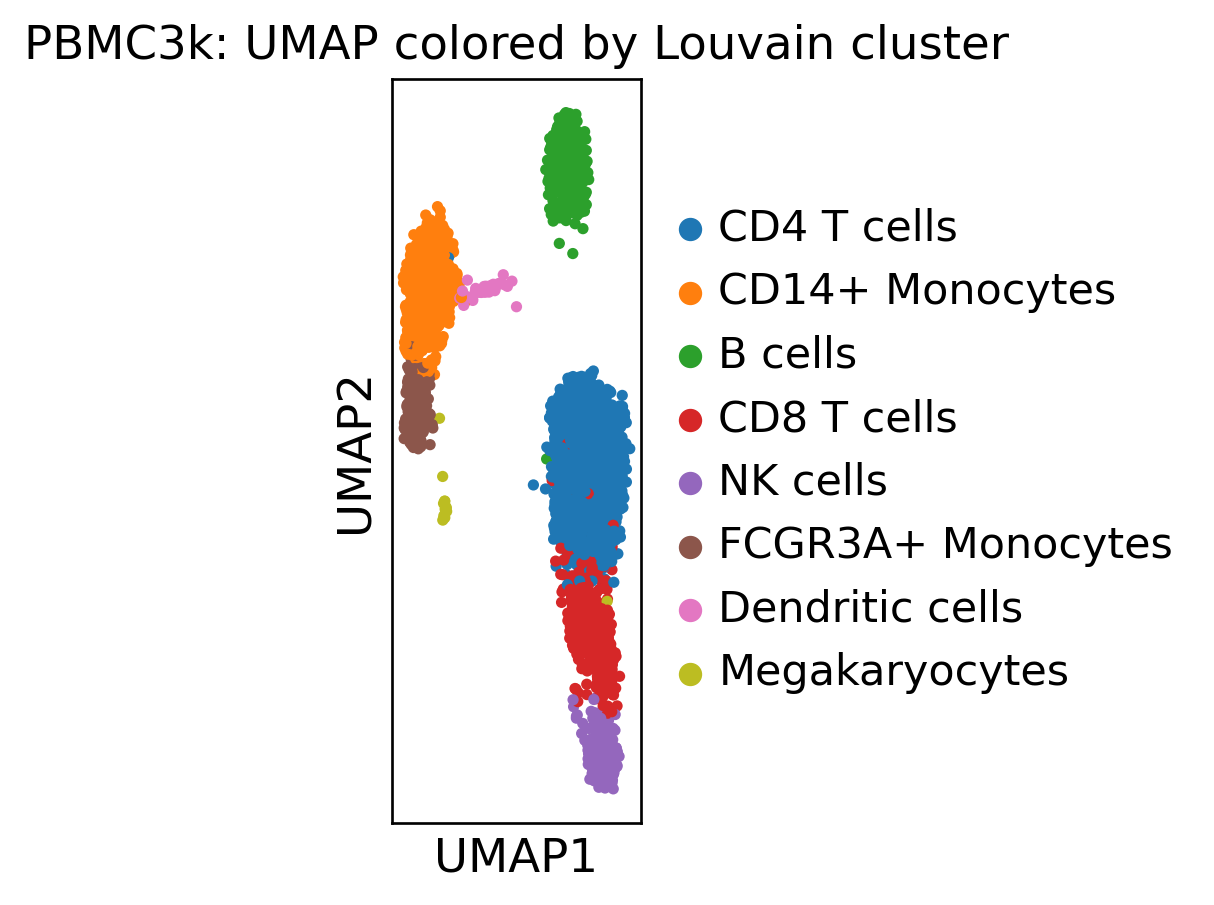

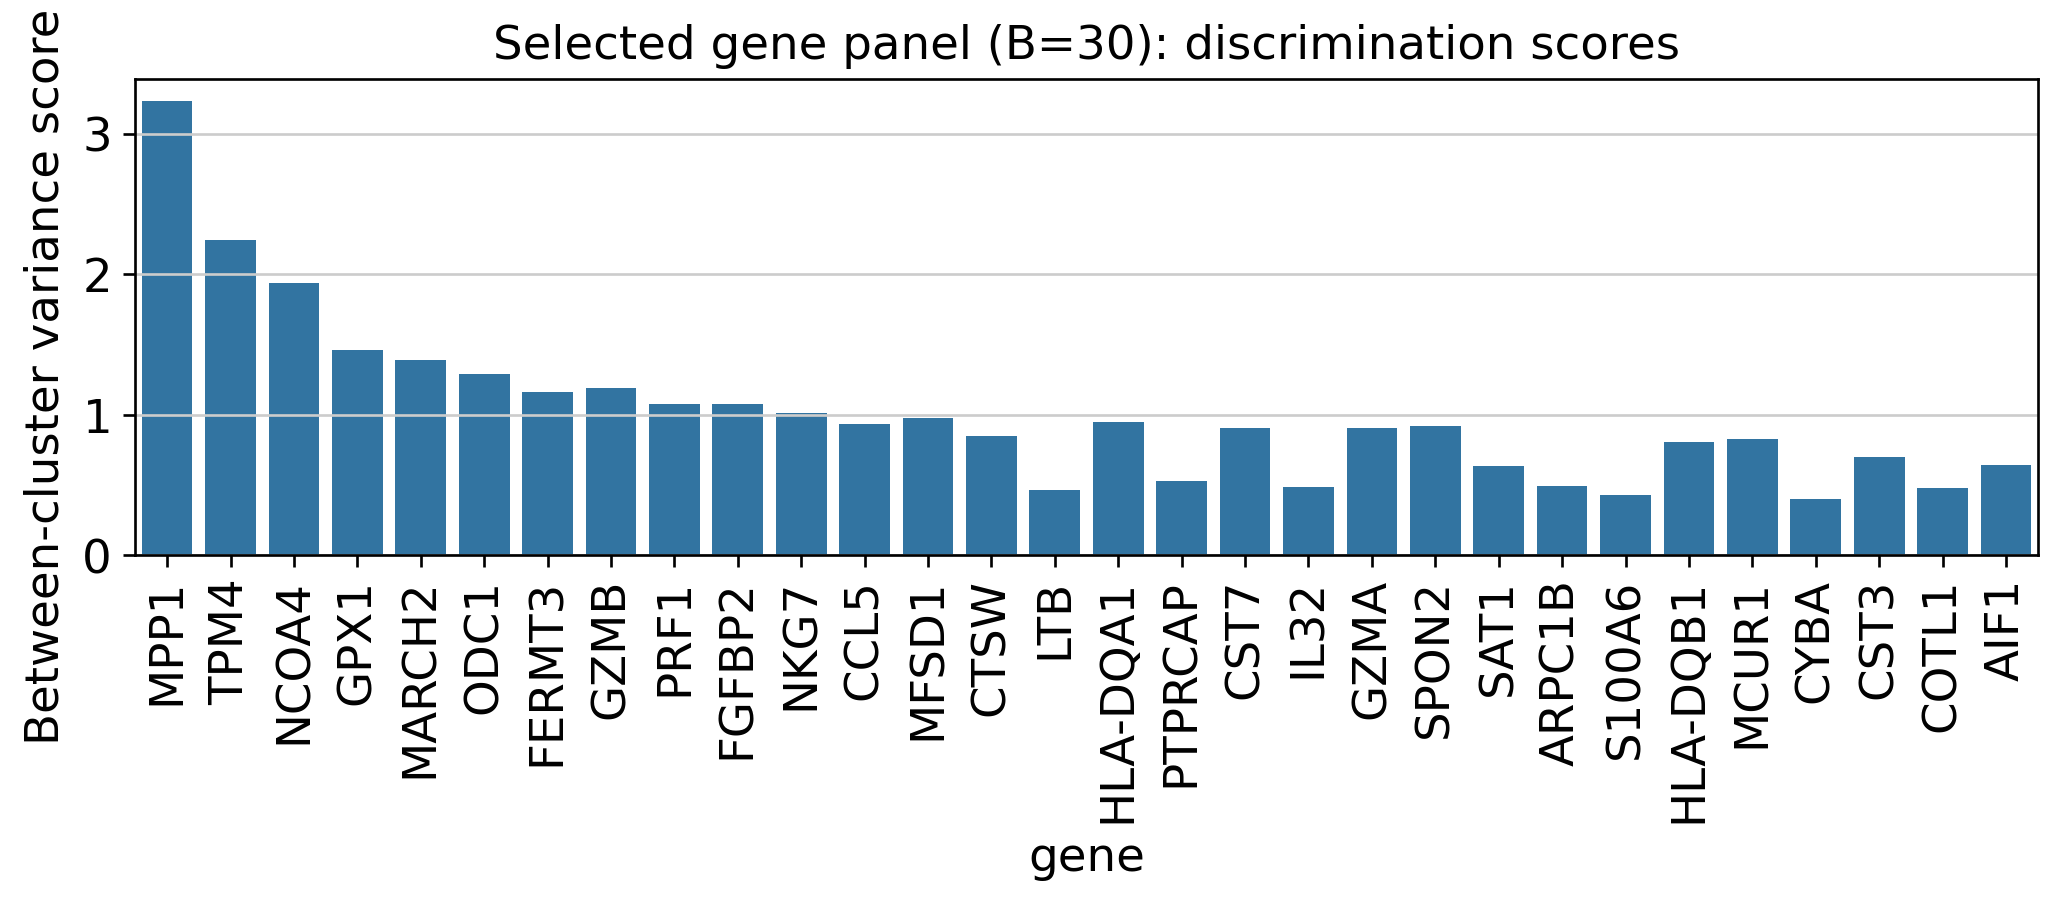

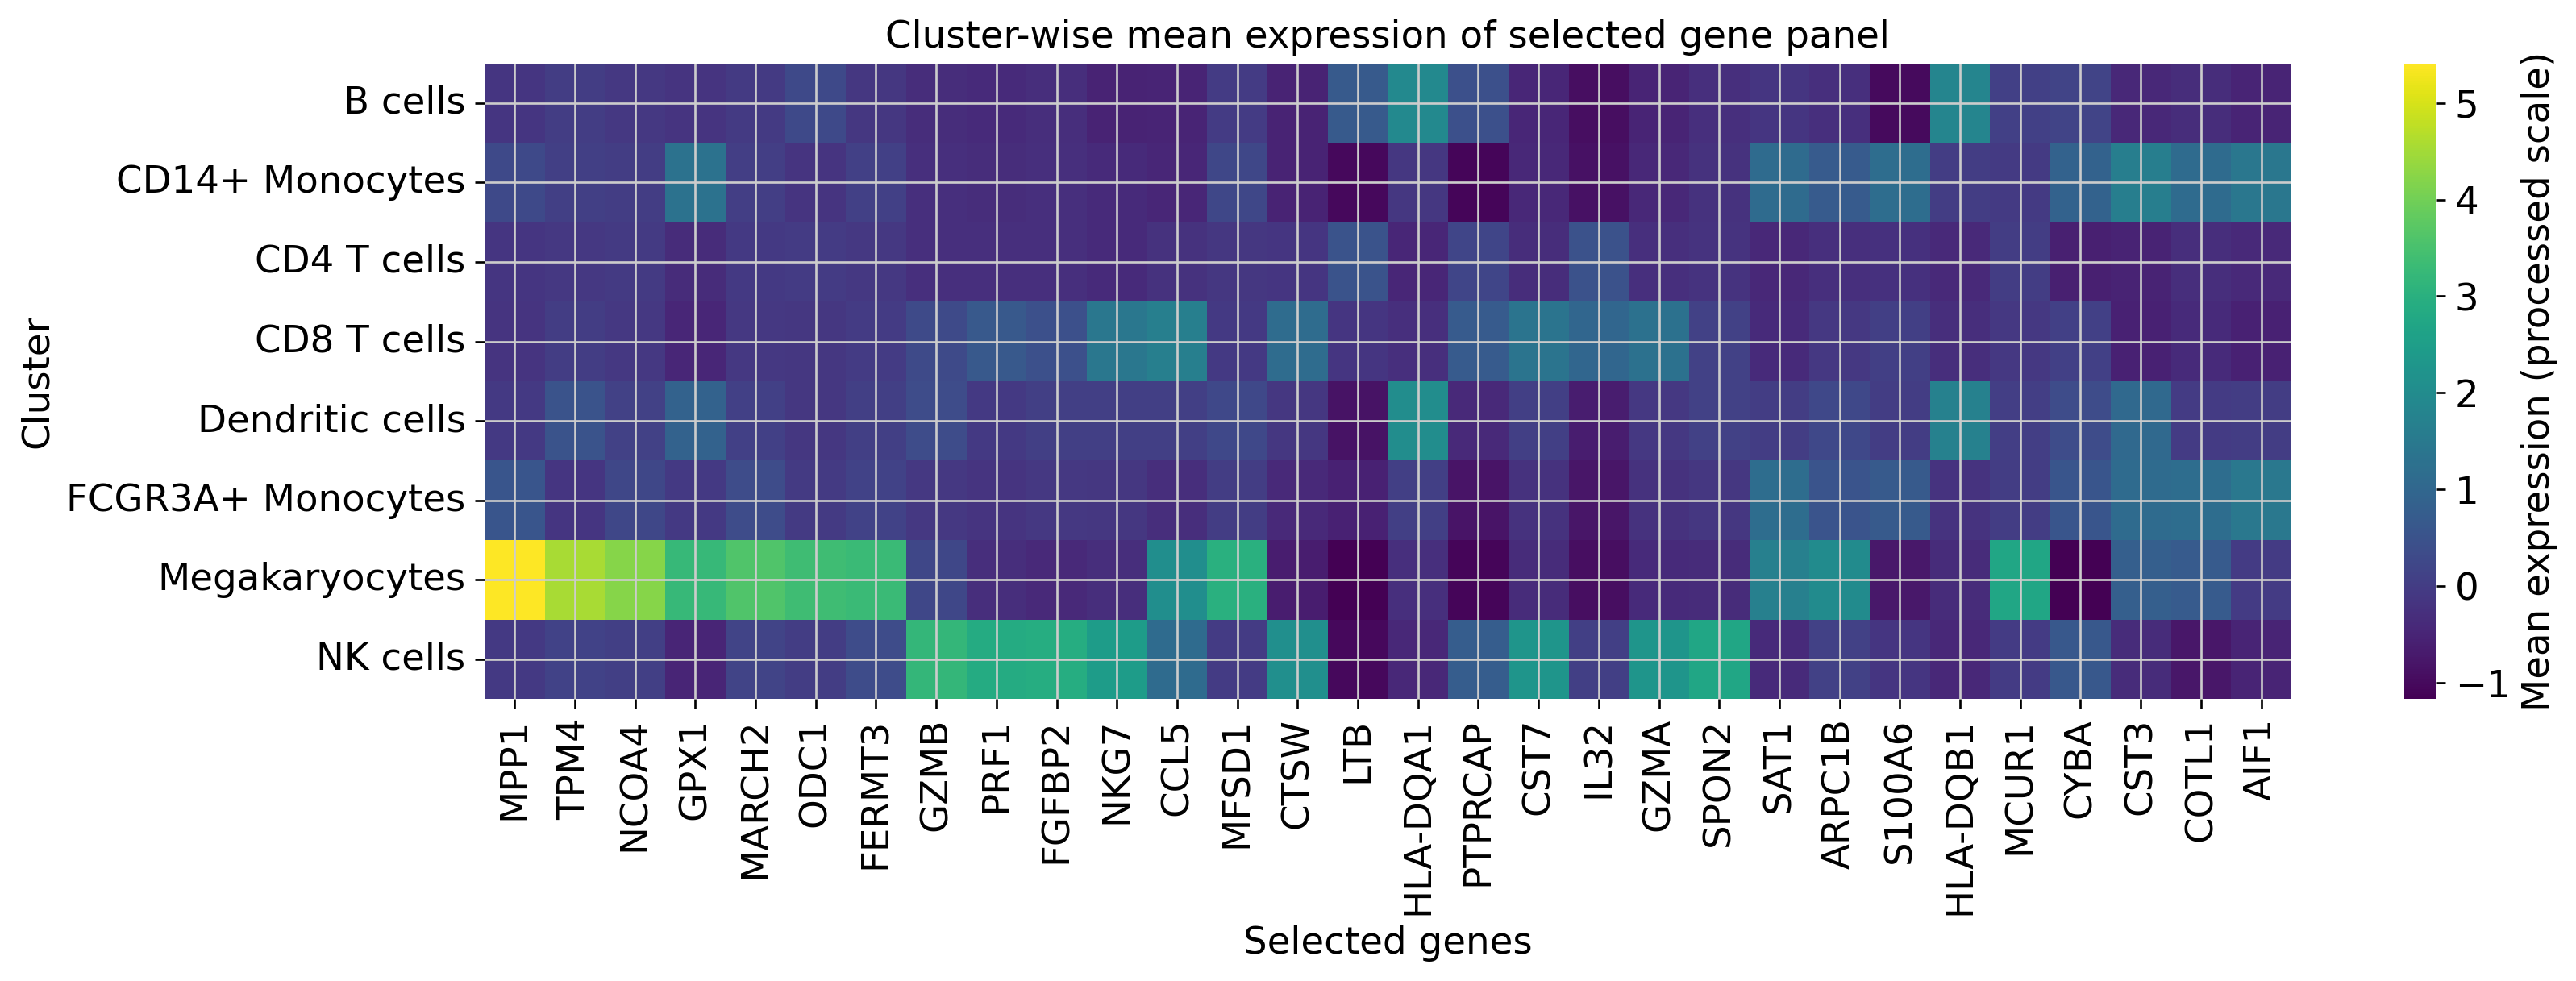

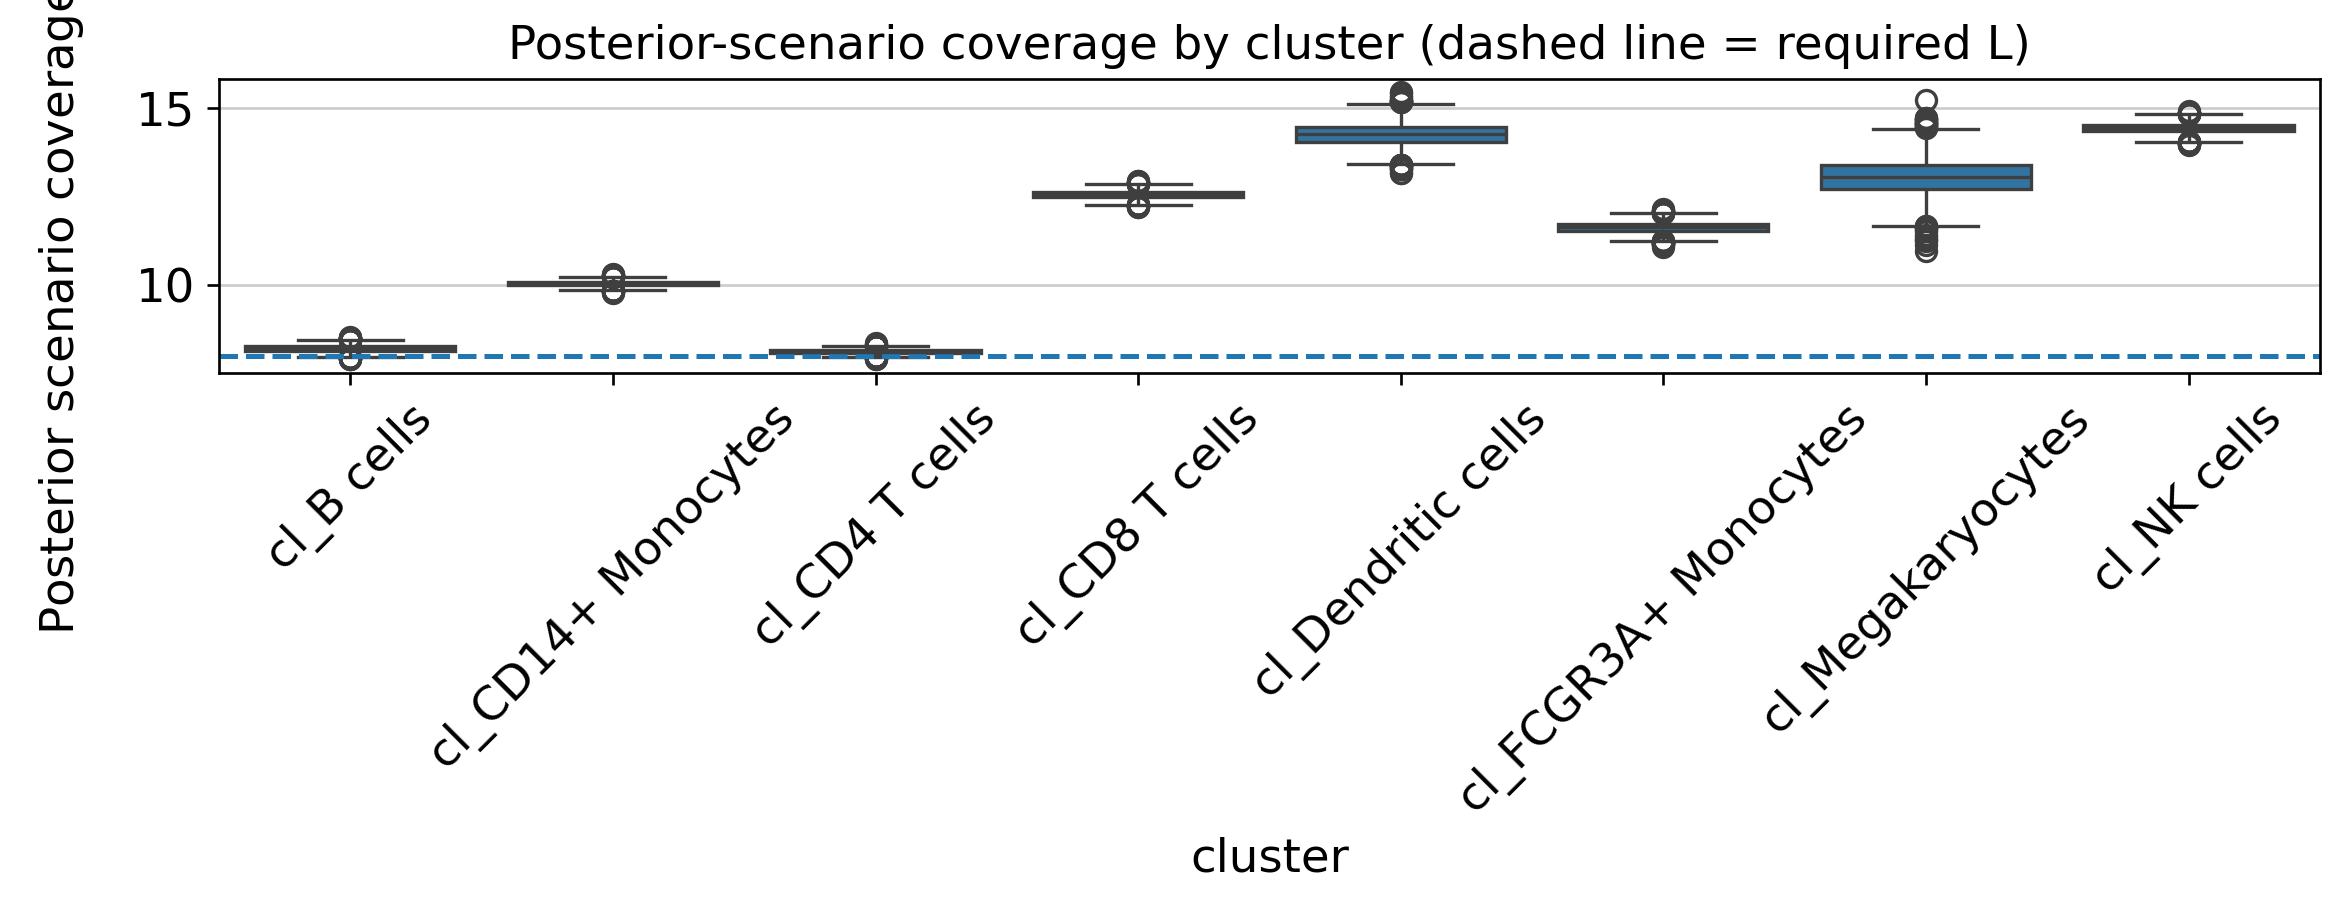

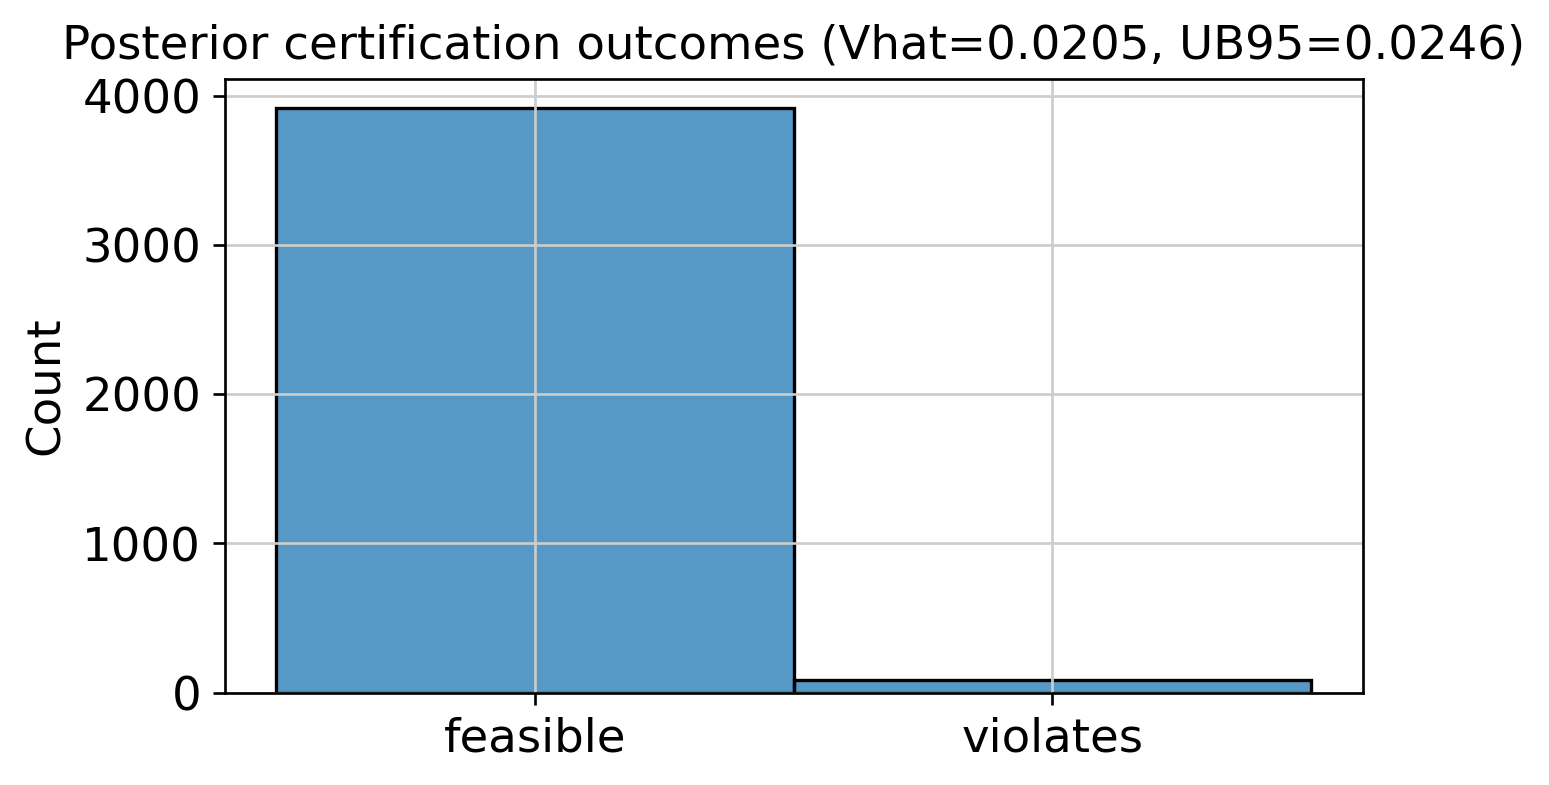

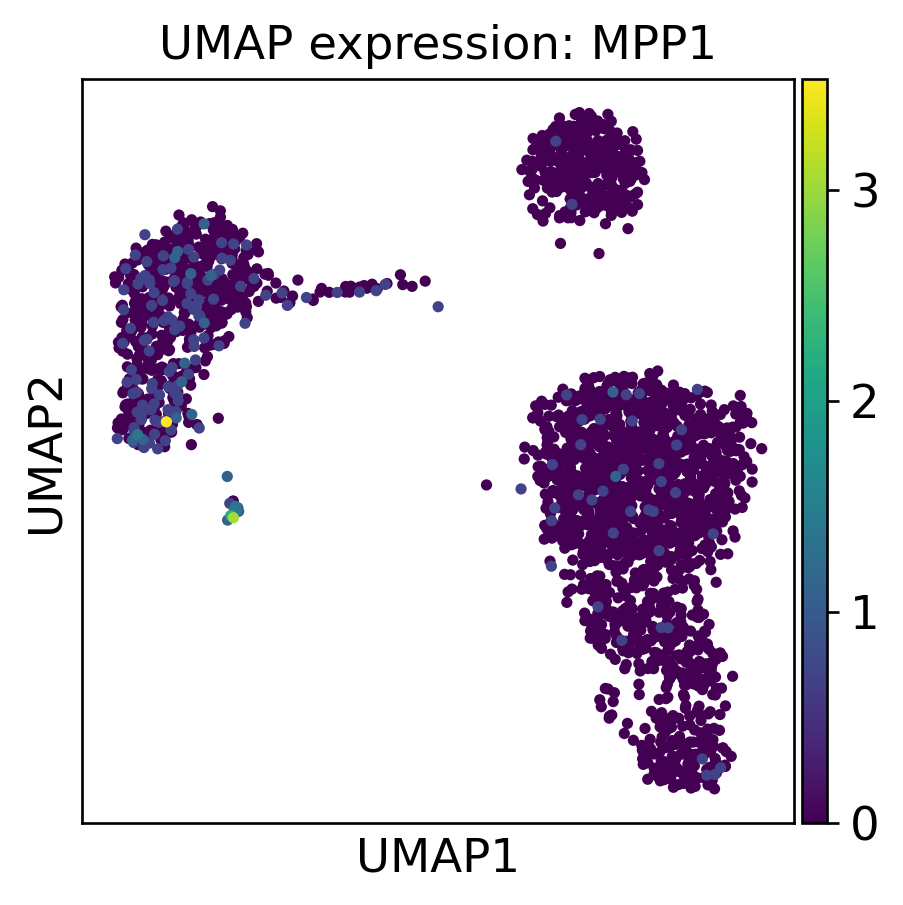

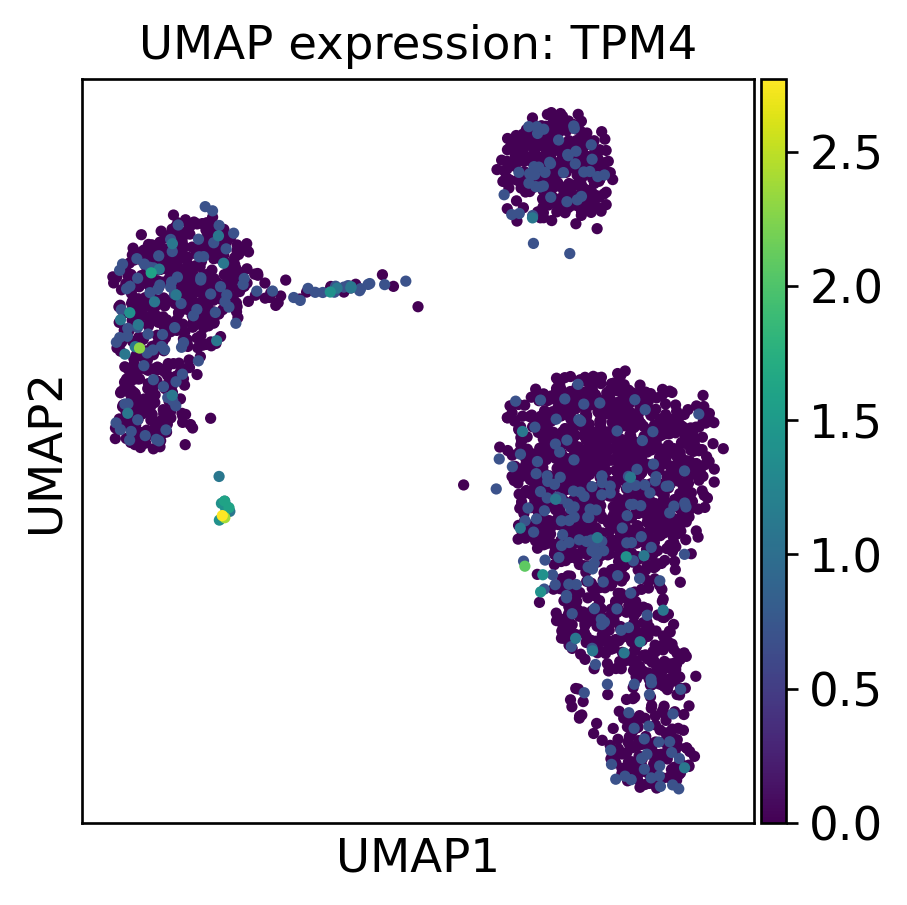

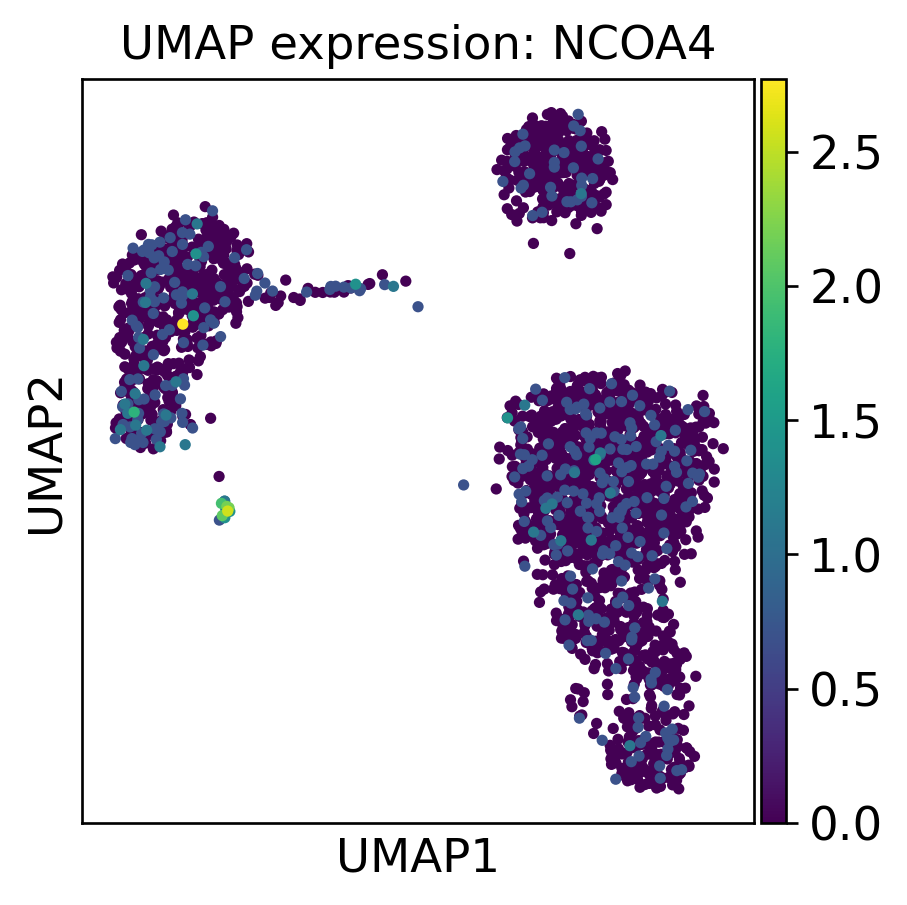

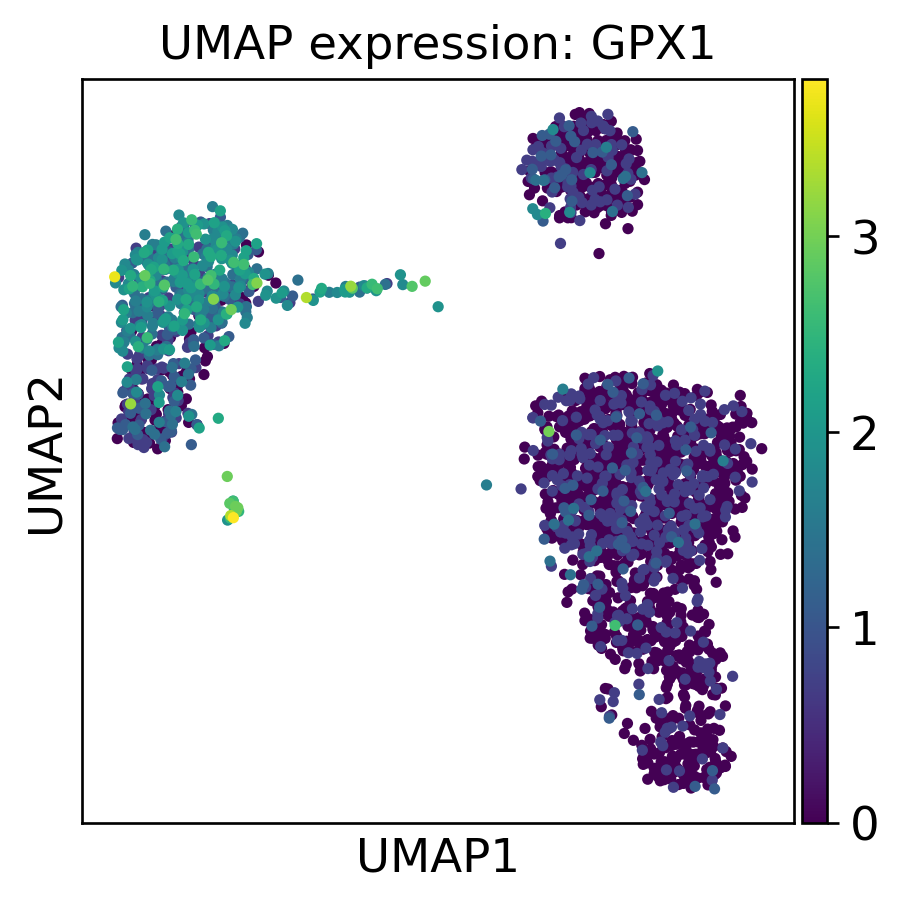

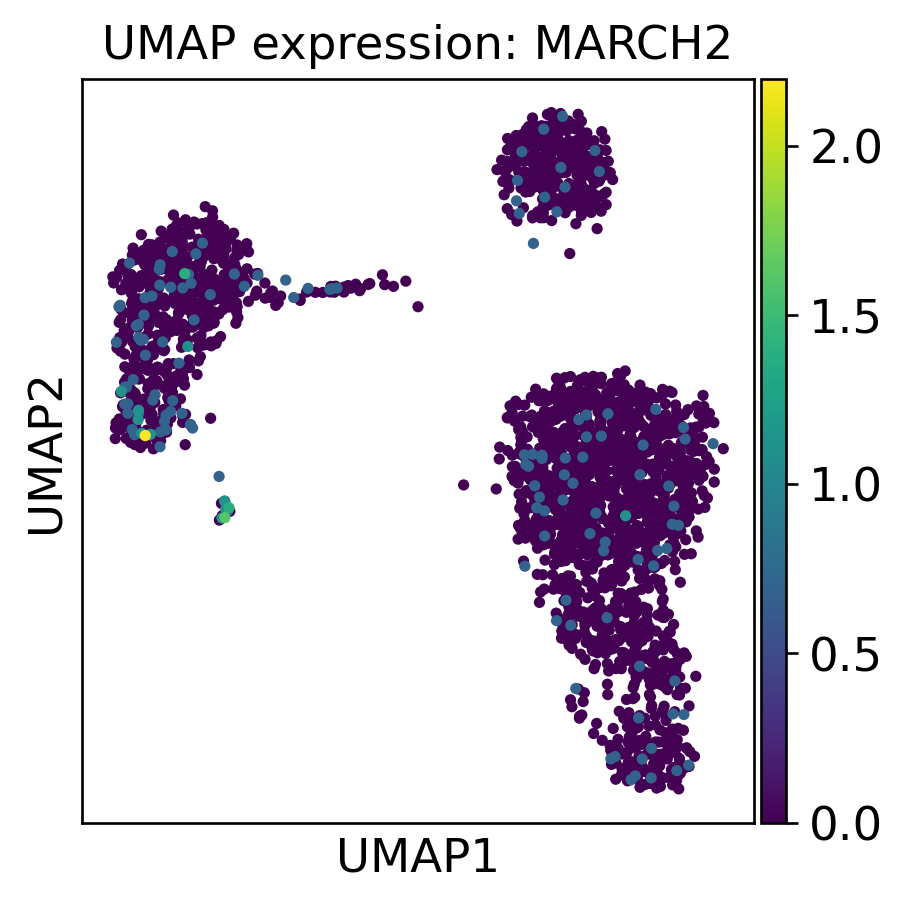

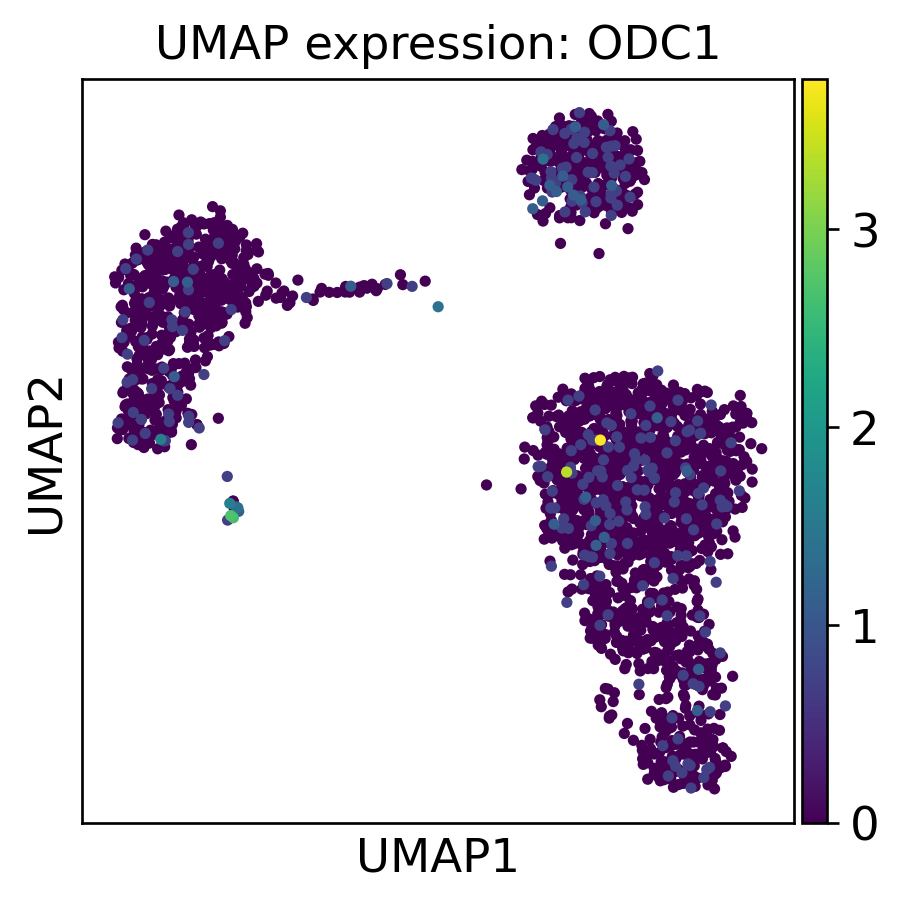

Wrote report: REALDATA_PBMC3K_BayesLP_20260306_025021/REPORT.md
Saved outputs to: REALDATA_PBMC3K_BayesLP_20260306_025021
Zipped as: REALDATA_PBMC3K_BayesLP_20260306_025021.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================
# Real-data demo (Genetics): Posterior-Scenario Bayesian LP
# Task: Safe gene-panel selection on PBMC3k scRNA-seq (Scanpy)
# Outputs: plots + tables + report + zip (auto-download in Colab)
# ============================================================

!pip -q install scanpy anndata pandas numpy scipy matplotlib seaborn tqdm cvxpy ecos

import os, time, zipfile, json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy import stats
import cvxpy as cp

import scanpy as sc

# Colab download helper
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ----------------------------
# 0) Repro + output dirs
# ----------------------------
SEED = 123
rng = np.random.default_rng(SEED)

RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")
BASE_DIR = f"REALDATA_PBMC3K_BayesLP_{RUN_STAMP}"
FIG_DIR = os.path.join(BASE_DIR, "figs")
TAB_DIR = os.path.join(BASE_DIR, "tables")
META_DIR = os.path.join(BASE_DIR, "meta")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

# ----------------------------
# 1) Load real genetic dataset (PBMC3k)
# ----------------------------
sc.settings.verbosity = 2
sc.set_figure_params(dpi=120, facecolor="white")

adata = sc.datasets.pbmc3k_processed()  # processed PBMC3k (AnnData)
# adata has: X (scaled/log), obs includes 'louvain' cluster labels, embeddings 'X_umap'
print(adata)

# Use clustering as "cell types" (unsupervised groups)
cluster_key = "louvain"
if cluster_key not in adata.obs.columns:
    raise ValueError("Expected louvain clusters in pbmc3k_processed(). Try pbmc3k() + clustering workflow.")
clusters = adata.obs[cluster_key].astype(str).values
uniq_clusters = np.unique(clusters)
J = len(uniq_clusters)
print("Clusters:", uniq_clusters, "J=", J)

# ----------------------------
# 2) Choose candidate genes
#    We'll pick genes with high between-cluster mean variance.
# ----------------------------
X = adata.X
if not sp.issparse(X):
    X = sp.csr_matrix(X)

gene_names = np.array(adata.var_names)

# Compute cluster means efficiently: mean expression per gene per cluster
# We'll use dense means for candidate subset to keep memory manageable.
# First choose a preliminary subset: top genes by global variance.
global_var = np.array(X.power(2).mean(axis=0)).ravel() - np.array(X.mean(axis=0)).ravel()**2
K0 = 600  # preliminary candidate pool size
idx0 = np.argsort(global_var)[::-1][:K0]
cand_genes = gene_names[idx0]
X0 = X[:, idx0].tocsr()

# Cluster-wise mean on candidate genes
cluster_means = np.zeros((J, K0), dtype=float)
for j, c in enumerate(uniq_clusters):
    mask = (clusters == c)
    Xcj = X0[mask]
    cluster_means[j, :] = np.array(Xcj.mean(axis=0)).ravel()

# Between-cluster separation score: variance of cluster means
w = cluster_means.var(axis=0)  # shape (K0,)
# Keep top K candidates by w
K = 300
idx = np.argsort(w)[::-1][:K]
genes = cand_genes[idx]
w = w[idx]
Xcand = X0[:, idx].tocsr()

# Save candidate list
pd.DataFrame({"gene": genes, "score_w": w}).to_csv(os.path.join(TAB_DIR, "candidate_genes.csv"), index=False)

print("Candidate gene pool K =", K)

# ----------------------------
# 3) Estimate posterior for detection probabilities q_{j,g}
#    Detection = (count > 0) in original (log/scale) matrix? pbmc3k_processed is scaled.
#    We instead use raw counts proxy:
#      use adata.raw if present; else use adata.X threshold > 0 as detection proxy.
# ----------------------------
if adata.raw is not None:
    Xdet_full = adata.raw.X
    raw_gene_names = np.array(adata.raw.var_names)
    # align genes (our subset genes must exist in raw)
    raw_index = {g:i for i,g in enumerate(raw_gene_names)}
    idx_raw = np.array([raw_index[g] for g in genes])
    Xdet = Xdet_full[:, idx_raw]
else:
    # fallback: use processed X as detection proxy (>0)
    Xdet = Xcand.copy()

if not sp.issparse(Xdet):
    Xdet = sp.csr_matrix(Xdet)

# Convert to binary detection matrix for candidate genes
Xbin = Xdet.copy().tocsr()
Xbin.data = np.ones_like(Xbin.data)

# Compute per-cluster detection counts (successes) for each gene
succ = np.zeros((J, K), dtype=float)
ncell = np.zeros(J, dtype=float)

for j, c in enumerate(uniq_clusters):
    mask = (clusters == c)
    ncell[j] = np.sum(mask)
    Xj = Xbin[mask]
    succ[j, :] = np.array(Xj.sum(axis=0)).ravel()

fail = ncell.reshape(-1,1) - succ

# Beta prior for detection probability q_{j,g}
a0, b0 = 1.0, 1.0  # uniform prior
a_post = a0 + succ
b_post = b0 + fail

# Posterior mean for reference
q_mean = a_post / (a_post + b_post)

# Save detection summary table (per cluster)
det_cluster_summary = pd.DataFrame({
    "cluster": uniq_clusters,
    "n_cells": ncell.astype(int),
})
det_cluster_summary.to_csv(os.path.join(TAB_DIR, "cluster_sizes.csv"), index=False)

# ----------------------------
# 4) Bayesian LP (Posterior-Scenario) for safe gene panel selection
# ----------------------------
# Budget and safety requirement
B = 30      # panel size (genes)
L = 8.0     # per-cluster expected detected genes among selected
alpha = 0.05  # "risk intent" (we'll mainly use it in reporting/certification)
S_scen = 300   # posterior scenarios used in optimization
M_cert = 4000  # posterior scenarios for certification

# Decision variables x_g in [0,1] (relaxation)
x = cp.Variable(K)

constraints = [
    x >= 0,
    x <= 1,
    cp.sum(x) <= B
]

# Posterior-scenario constraints:
# For s=1..S, sample q^{(s)}_{j,g} ~ Beta(a_post, b_post),
# enforce sum_g q_{j,g}^{(s)} x_g >= L for all clusters j.
# This is linear in x once q samples are drawn.

def sample_q_scenarios(a_post, b_post, S, rng):
    # returns array shape (S, J, K)
    return rng.beta(a_post[None, :, :], b_post[None, :, :], size=(S,)+a_post.shape)

print("Sampling posterior scenarios for optimization...")
Qscen = sample_q_scenarios(a_post, b_post, S_scen, rng)  # (S,J,K)

for s in range(S_scen):
    # For each cluster j: sum_g Qscen[s,j,g] * x_g >= L
    constraints.append(Qscen[s] @ x >= L)

# Objective: maximize discrimination score
objective = cp.Maximize(w @ x)

prob = cp.Problem(objective, constraints)
print("Solving Bayesian LP (Posterior-Scenario)...")
prob.solve(solver="ECOS", verbose=False)

print("Status:", prob.status, "Objective:", prob.value)

xval = np.array(x.value).reshape(-1)
# Pick top B genes by x (relaxed -> hard selection)
top_idx = np.argsort(xval)[::-1][:B]
panel_genes = genes[top_idx]
panel_scores = w[top_idx]
panel_x = xval[top_idx]

panel_df = pd.DataFrame({
    "rank": np.arange(1, B+1),
    "gene": panel_genes,
    "x_relaxed": panel_x,
    "score_w": panel_scores
})
panel_df.to_csv(os.path.join(TAB_DIR, "selected_gene_panel.csv"), index=False)
display(panel_df.head(15))

# ----------------------------
# 5) Posterior feasibility certificate (Monte Carlo)
#    Estimate violation probability under posterior:
#      violation if any cluster has sum_g q_{j,g} x_g < L
# ----------------------------
print("Certifying posterior feasibility via independent posterior draws...")
Qcert = sample_q_scenarios(a_post, b_post, M_cert, rng)  # (M,J,K)
lhs = Qcert @ xval  # shape (M, J)
viol = np.any(lhs < L, axis=1)
Vhat = viol.mean()

# Clopper-Pearson upper bound (95%)
s_viol = int(viol.sum())
UB95 = float(stats.beta.ppf(0.95, s_viol + 1, M_cert - s_viol)) if s_viol < M_cert else 1.0

cert_df = pd.DataFrame([{
    "alpha_intent": alpha,
    "B_panel": B,
    "L_required": L,
    "S_scen_optim": S_scen,
    "M_cert": M_cert,
    "posterior_violation_hat": Vhat,
    "posterior_violation_UB95": UB95
}])
cert_df.to_csv(os.path.join(TAB_DIR, "posterior_certificate.csv"), index=False)
display(cert_df)

# Cluster-wise shortfall stats
shortfall = np.maximum(0.0, L - lhs)  # (M,J)
cluster_cert = pd.DataFrame({
    "cluster": uniq_clusters,
    "mean_coverage": lhs.mean(axis=0),
    "p5_coverage": np.quantile(lhs, 0.05, axis=0),
    "p50_coverage": np.quantile(lhs, 0.50, axis=0),
    "p95_coverage": np.quantile(lhs, 0.95, axis=0),
    "viol_rate_cluster": np.mean(lhs < L, axis=0)
})
cluster_cert.to_csv(os.path.join(TAB_DIR, "cluster_certificate_detail.csv"), index=False)
display(cluster_cert)

# ----------------------------
# 6) Plots (colorful) + saving
# ----------------------------
def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.show()
    plt.close()

# (A) UMAP colored by cluster
sc.pl.umap(adata, color=cluster_key, show=False)
plt.title("PBMC3k: UMAP colored by Louvain cluster")
savefig(os.path.join(FIG_DIR, "umap_clusters.png"))

# (B) Top genes: bar plot of discrimination score
plt.figure(figsize=(9,4))
sns.barplot(x=panel_df["gene"].astype(str), y=panel_df["score_w"])
plt.xticks(rotation=90)
plt.ylabel("Between-cluster variance score w(g)")
plt.title(f"Selected gene panel (B={B}): discrimination scores")
savefig(os.path.join(FIG_DIR, "panel_gene_scores.png"))

# (C) Heatmap: mean expression of selected genes across clusters
# Use processed expression for visualization (scaled/log)
# Compute cluster means for selected genes
# Find selected gene indices in adata.var_names (processed)
var_index = {g:i for i,g in enumerate(adata.var_names)}
sel_idx_proc = np.array([var_index[g] for g in panel_genes])
Xviz = adata.X[:, sel_idx_proc]
if not sp.issparse(Xviz):
    Xviz = sp.csr_matrix(Xviz)

means_sel = np.zeros((J, B))
for j, c in enumerate(uniq_clusters):
    mask = (clusters == c)
    means_sel[j,:] = np.array(Xviz[mask].mean(axis=0)).ravel()

hm = pd.DataFrame(means_sel, index=uniq_clusters, columns=panel_genes)

plt.figure(figsize=(0.35*B + 4, 0.35*J + 2.5))
sns.heatmap(hm, cmap="viridis", cbar_kws={"label":"Mean expression (processed scale)"})
plt.xlabel("Selected genes")
plt.ylabel("Cluster")
plt.title("Cluster-wise mean expression of selected gene panel")
savefig(os.path.join(FIG_DIR, "heatmap_cluster_means_selected_genes.png"))

# (D) Posterior coverage distributions per cluster (boxplot)
lhs_df = pd.DataFrame(lhs, columns=[f"cl_{c}" for c in uniq_clusters])
lhs_melt = lhs_df.melt(var_name="cluster", value_name="coverage")

plt.figure(figsize=(10,4))
sns.boxplot(data=lhs_melt, x="cluster", y="coverage")
plt.axhline(L, linestyle="--")
plt.xticks(rotation=45)
plt.ylabel(r"Posterior scenario coverage $\sum_g q_{jg} x_g$")
plt.title("Posterior-scenario coverage by cluster (dashed line = required L)")
savefig(os.path.join(FIG_DIR, "posterior_coverage_boxplot.png"))

# (E) Violation indicator plot
plt.figure(figsize=(6,3.5))
sns.histplot(viol.astype(int), bins=3, discrete=True)
plt.xticks([0,1], ["feasible", "violates"])
plt.title(f"Posterior certification outcomes (Vhat={Vhat:.4f}, UB95={UB95:.4f})")
savefig(os.path.join(FIG_DIR, "posterior_violation_hist.png"))

# (F) Feature plots for a few top genes
top_show = min(6, B)
for g in panel_genes[:top_show]:
    sc.pl.umap(adata, color=g, show=False)
    plt.title(f"UMAP expression: {g}")
    savefig(os.path.join(FIG_DIR, f"umap_gene_{g}.png"))

# ----------------------------
# 7) Paper-style report (markdown) + zip
# ----------------------------
report_path = os.path.join(BASE_DIR, "REPORT.md")
with open(report_path, "w") as f:
    f.write("# Real-data demonstration: Bayesian LP with posterior feasibility (PBMC3k)\n\n")
    f.write("## Dataset\n")
    f.write("- Scanpy PBMC3k processed scRNA-seq dataset (clusters via Louvain).\n\n")
    f.write("## Task\n")
    f.write(f"- Select a gene panel of size B={B} maximizing between-cluster separation score.\n")
    f.write(f"- Posterior-feasibility constraint: for each cluster, expected detectable genes among selected >= L={L} across posterior scenarios.\n\n")
    f.write("## Posterior certificate\n\n")
    f.write(cert_df.to_markdown(index=False, floatfmt=".6f"))
    f.write("\n\n## Cluster-wise certificate detail\n\n")
    f.write(cluster_cert.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n## Selected gene panel\n\n")
    f.write(panel_df.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n## Figures generated\n")
    for fn in sorted(os.listdir(FIG_DIR)):
        f.write(f"- {fn}\n")

print("Wrote report:", report_path)

# Zip everything
zip_path = f"{BASE_DIR}.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files_ in os.walk(BASE_DIR):
        for fn in files_:
            full = os.path.join(root, fn)
            rel = os.path.relpath(full, start=os.path.dirname(BASE_DIR))
            zf.write(full, rel)

print("Saved outputs to:", BASE_DIR)
print("Zipped as:", zip_path)

if IN_COLAB:
    files.download(zip_path)